In [141]:
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/lpsha/s154446/fractality')
from dgdc import get_dual_dir_con
import momepy
import numpy as np

import importlib
import space_filling
importlib.reload(space_filling)
from space_filling import get_geodataframe
import powerlaw

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [177]:
# Model 1
model1 = get_geodataframe(model=1, min_length=0.02)

model1['osmid'] = model1.index
G = momepy.gdf_to_nx(model1, approach='primal')
gdf_merged1, _, _, _ = get_dual_dir_con(t_buffer=1, a_threshold=20, data=G, enforce_degree2=False)

  Model 1: converged at iteration 2177 with 4362 segments


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


roundabout simplification failed: could not broadcast input array from shape (0,18) into shape (0,)


In [ ]:
# Model 2
model2 = get_geodataframe(model=2, min_angle=np.pi/4, area_coeff=0.03, min_length=0.02) #angle 45 degree

model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=1, a_threshold=20, data=G, enforce_degree2=False)

  Model 2: converged at iteration 1639 with 3095 segments


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


roundabout simplification applied


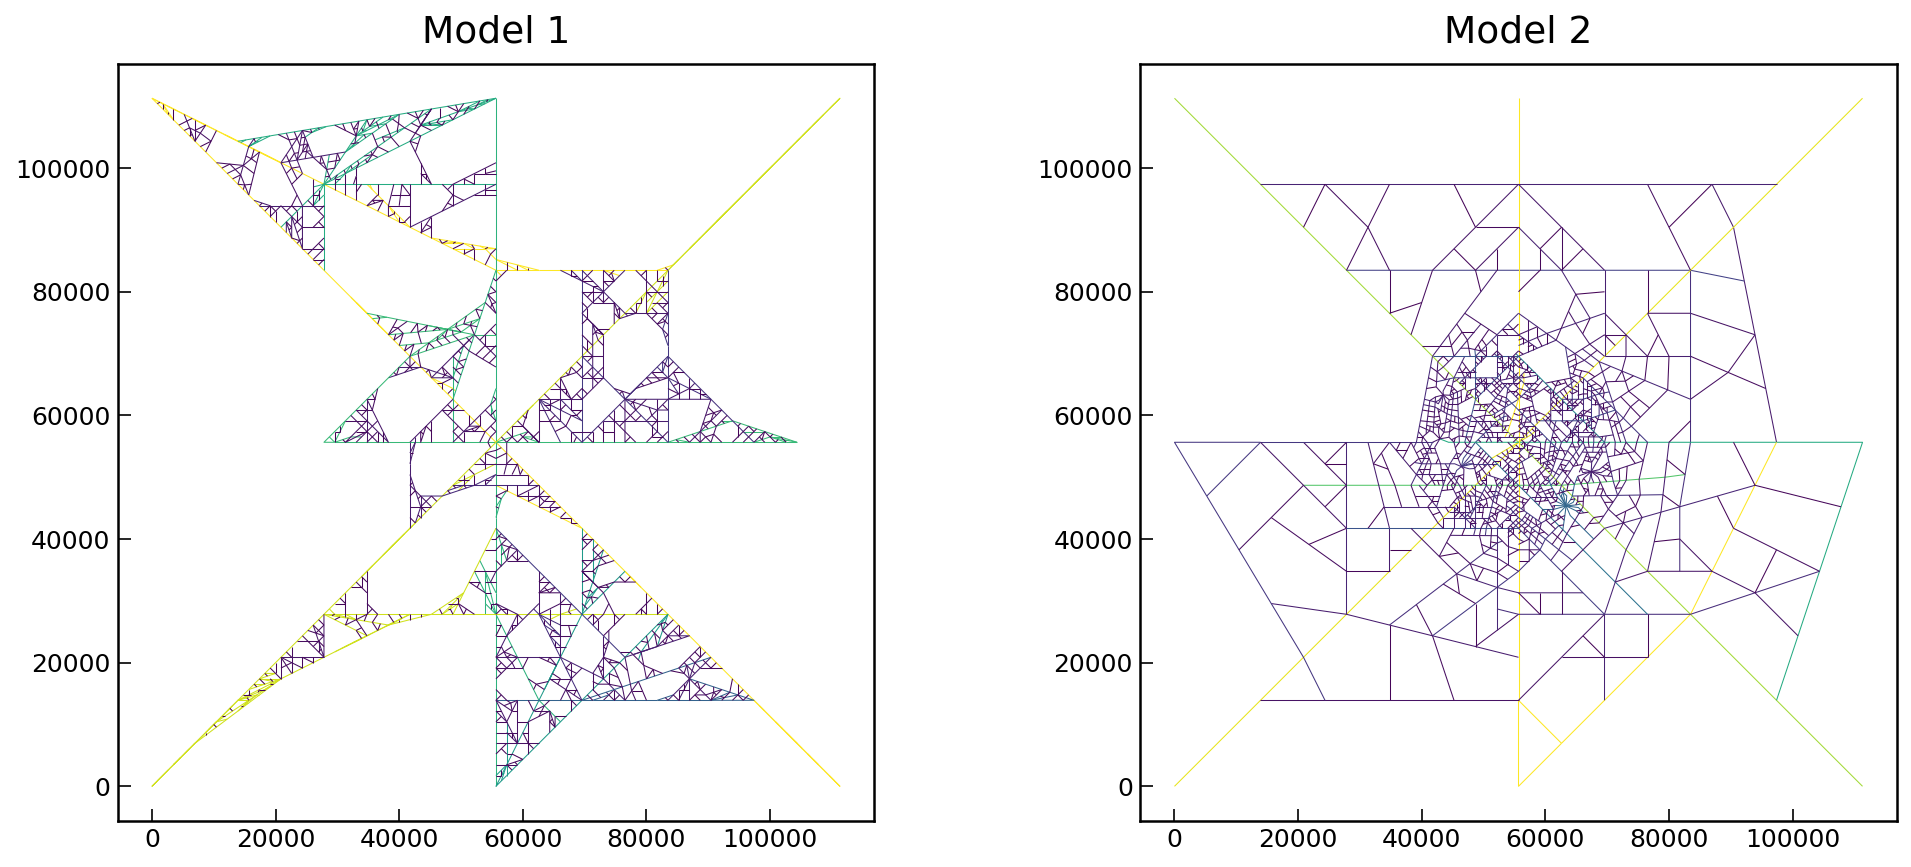

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

gdf_merged1.plot(ax=axes[0], column='degree', linewidth=0.5)
axes[0].set_title('Model 1')
axes[0].set_aspect('equal')

gdf_merged2.plot(ax=axes[1], column='degree', linewidth=0.5)
axes[1].set_title('Model 2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

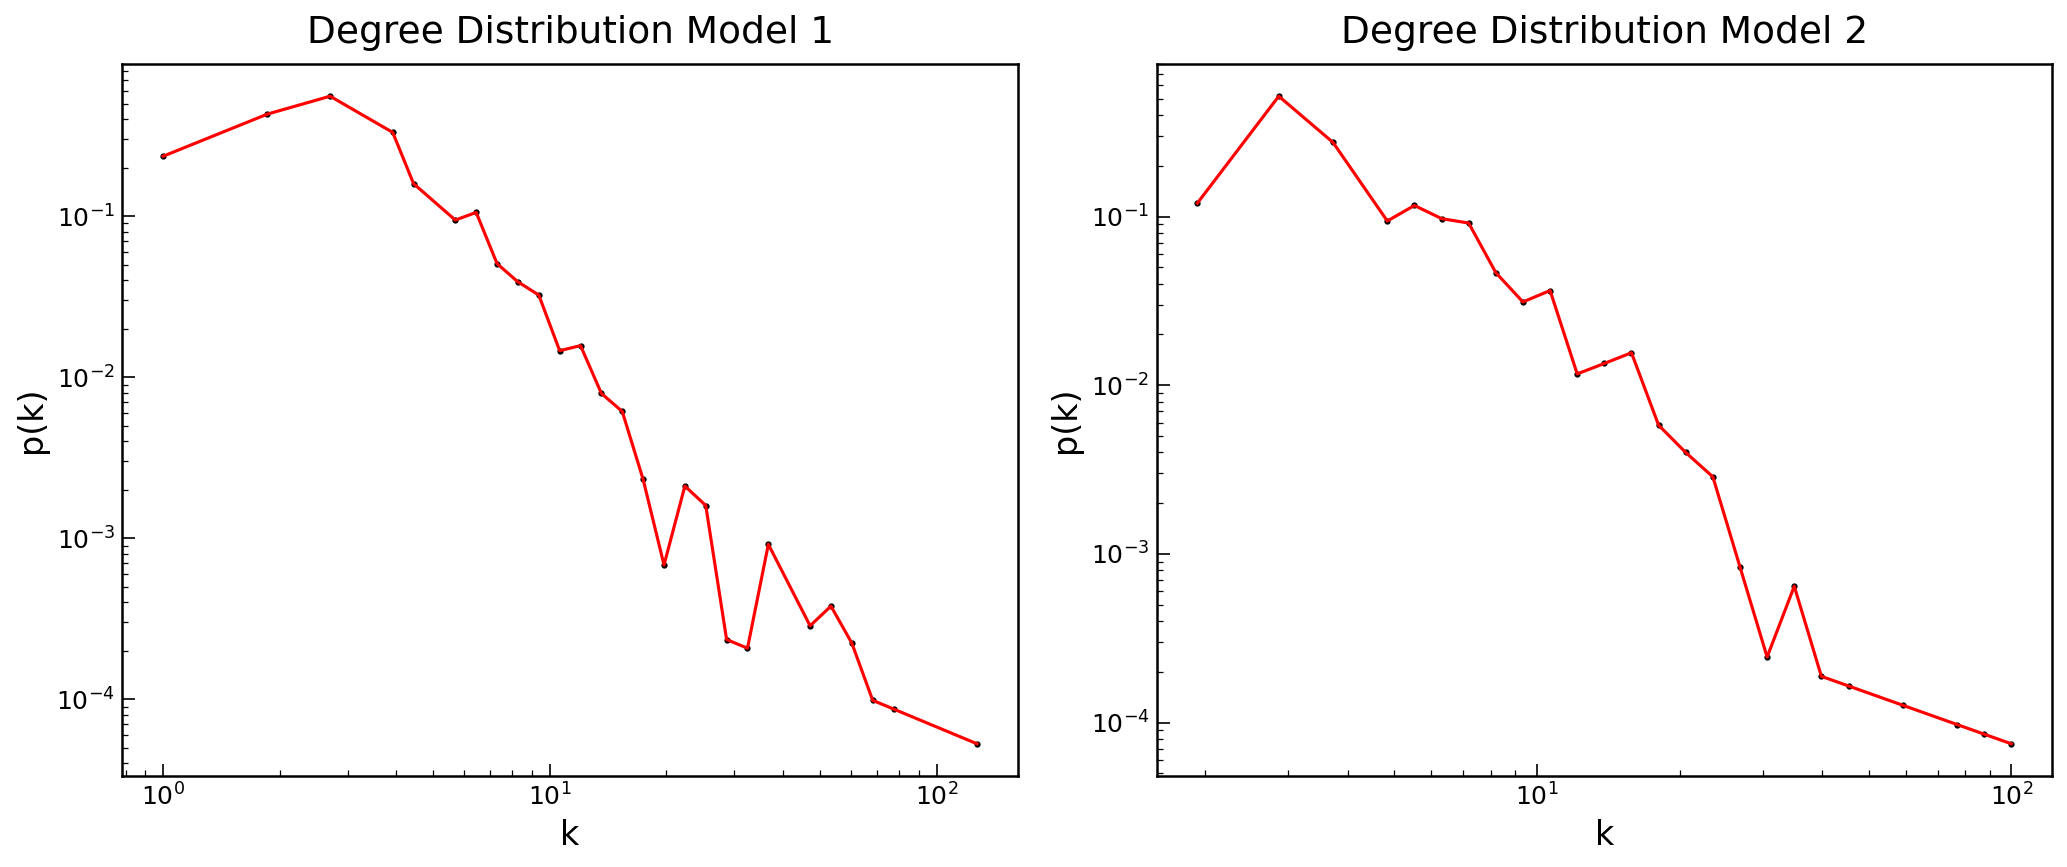

In [174]:
real_degree_sequence1=gdf_merged1['degree'].values
real_degree_sequence2=gdf_merged2['degree'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6),dpi=150)

ax = axs[0]
y, x = np.histogram(real_degree_sequence1, bins=np.logspace(0, np.log10(real_degree_sequence1.max()), len(np.unique(real_degree_sequence1))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.scatter(x_nn, y_nn, alpha=1, zorder=1, color='k', s=4)
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')
ax.set_ylabel('p(k)')
ax.set_xlabel('k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution Model 1")

ax = axs[1]
y, x = np.histogram(real_degree_sequence2, bins=np.logspace(0, np.log10(real_degree_sequence2.max()), len(np.unique(real_degree_sequence2))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.scatter(x_nn, y_nn, alpha=1, zorder=1, color='k', s=4)
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')
ax.set_ylabel('p(k)')
ax.set_xlabel('k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution Model 2")

plt.tight_layout()
plt.show()

In [175]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        ass.append(a) 

    return np.array(distance), min_range, ass

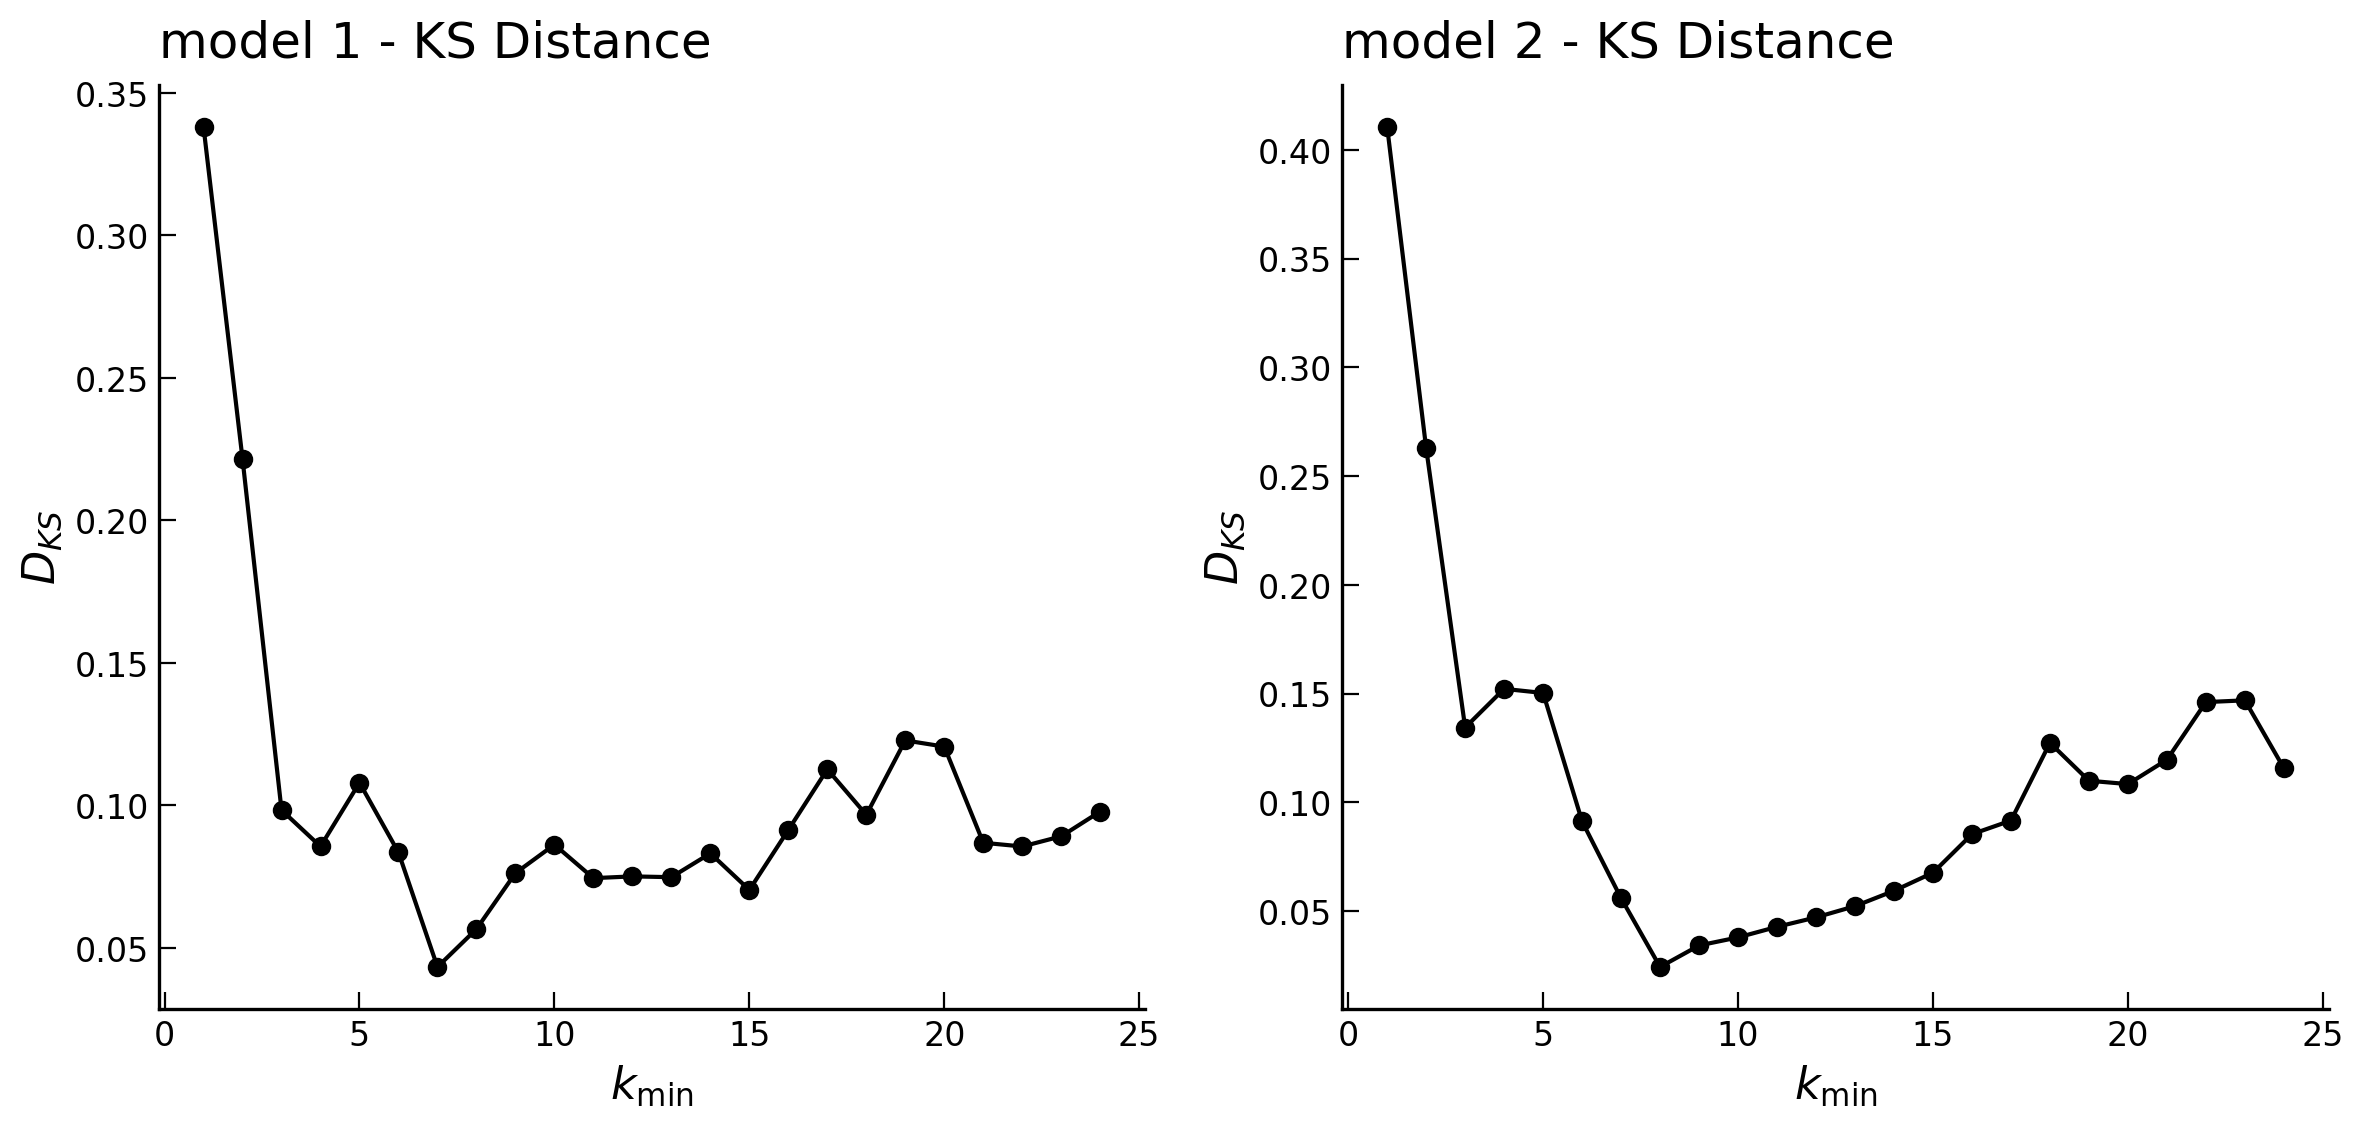

In [176]:
d=real_degree_sequence1
d=d[d != 0]
ks_dist1, xmins1, _ = compute_ks(d, range(1,25))

d2=real_degree_sequence2
d2=d2[d2 != 0]
ks_dist2, xmins2, _ = compute_ks(d2, range(1,25))

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,dpi=200,figsize=(14,6))

ax1.scatter(xmins1,ks_dist1,color='k')
ax1.plot(xmins1,ks_dist1,color='k')
ax1.set_xlabel(r'$k_{\min}$')
ax1.set_ylabel(r'$D_{KS}$')
ax1.set_title('model 1 - KS Distance', loc='left')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')

ax2.scatter(xmins2,ks_dist2,color='k')
ax2.plot(xmins2,ks_dist2,color='k')
ax2.set_xlabel(r'$k_{\min}$')
ax2.set_ylabel(r'$D_{KS}$')
ax2.set_title('model 2 - KS Distance', loc='left')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')

# ax2.axvline(x=8, color='k', linestyle='--', label='Degree 2')
plt.show()

In [3]:
d2

NameError: name 'd2' is not defined